<a href="https://colab.research.google.com/github/Saranya546/creditcard/blob/main/DAY_3_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# credit card fraud detection


In [ ]:
# downloading the dataset
!pip install kaggle


In [2]:
!mkdir -p ~/.kaggle

In [3]:
import json
import os

kaggle_info = {
    "username": "bulusulakshmisaranya",
    "key": "KGAT_8360fc1d43ff22cdf1373463b1edfc57"
}

# Create the .kaggle directory if it doesn't exist
os.makedirs('/root/.kaggle/', exist_ok=True)

with open('/root/.kaggle/kaggle.json', 'w') as file:
    json.dump(kaggle_info, file)

In [4]:
!chmod 600 /root/.kaggle/kaggle.json

In [5]:
!kaggle datasets download -d mlg-ulb/creditcardfraud

Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
100% 66.0M/66.0M [00:00<00:00, 101MB/s]



In [6]:
!unzip creditcardfraud.zip

Archive:  creditcardfraud.zip
  inflating: creditcard.csv          


In [7]:
import pandas as pd

df = pd.read_csv("creditcard.csv")

print(df.head())
print(df.shape)

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

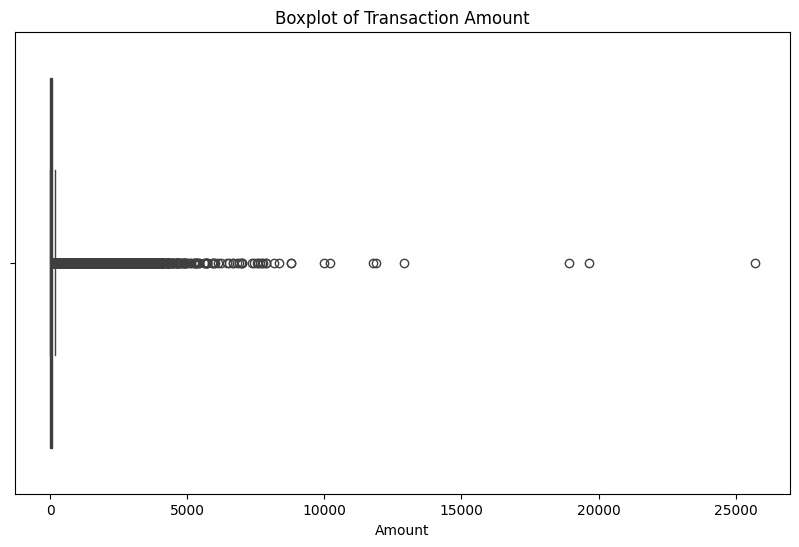

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Amount'])
plt.title('Boxplot of Transaction Amount')
plt.xlabel('Amount')
plt.show()

In [ ]:
null_counts = df.isnull().sum()
print("Sum of null values for each feature:")
print(null_counts[null_counts > 0])

Sum of null values for each feature:
Series([], dtype: int64)


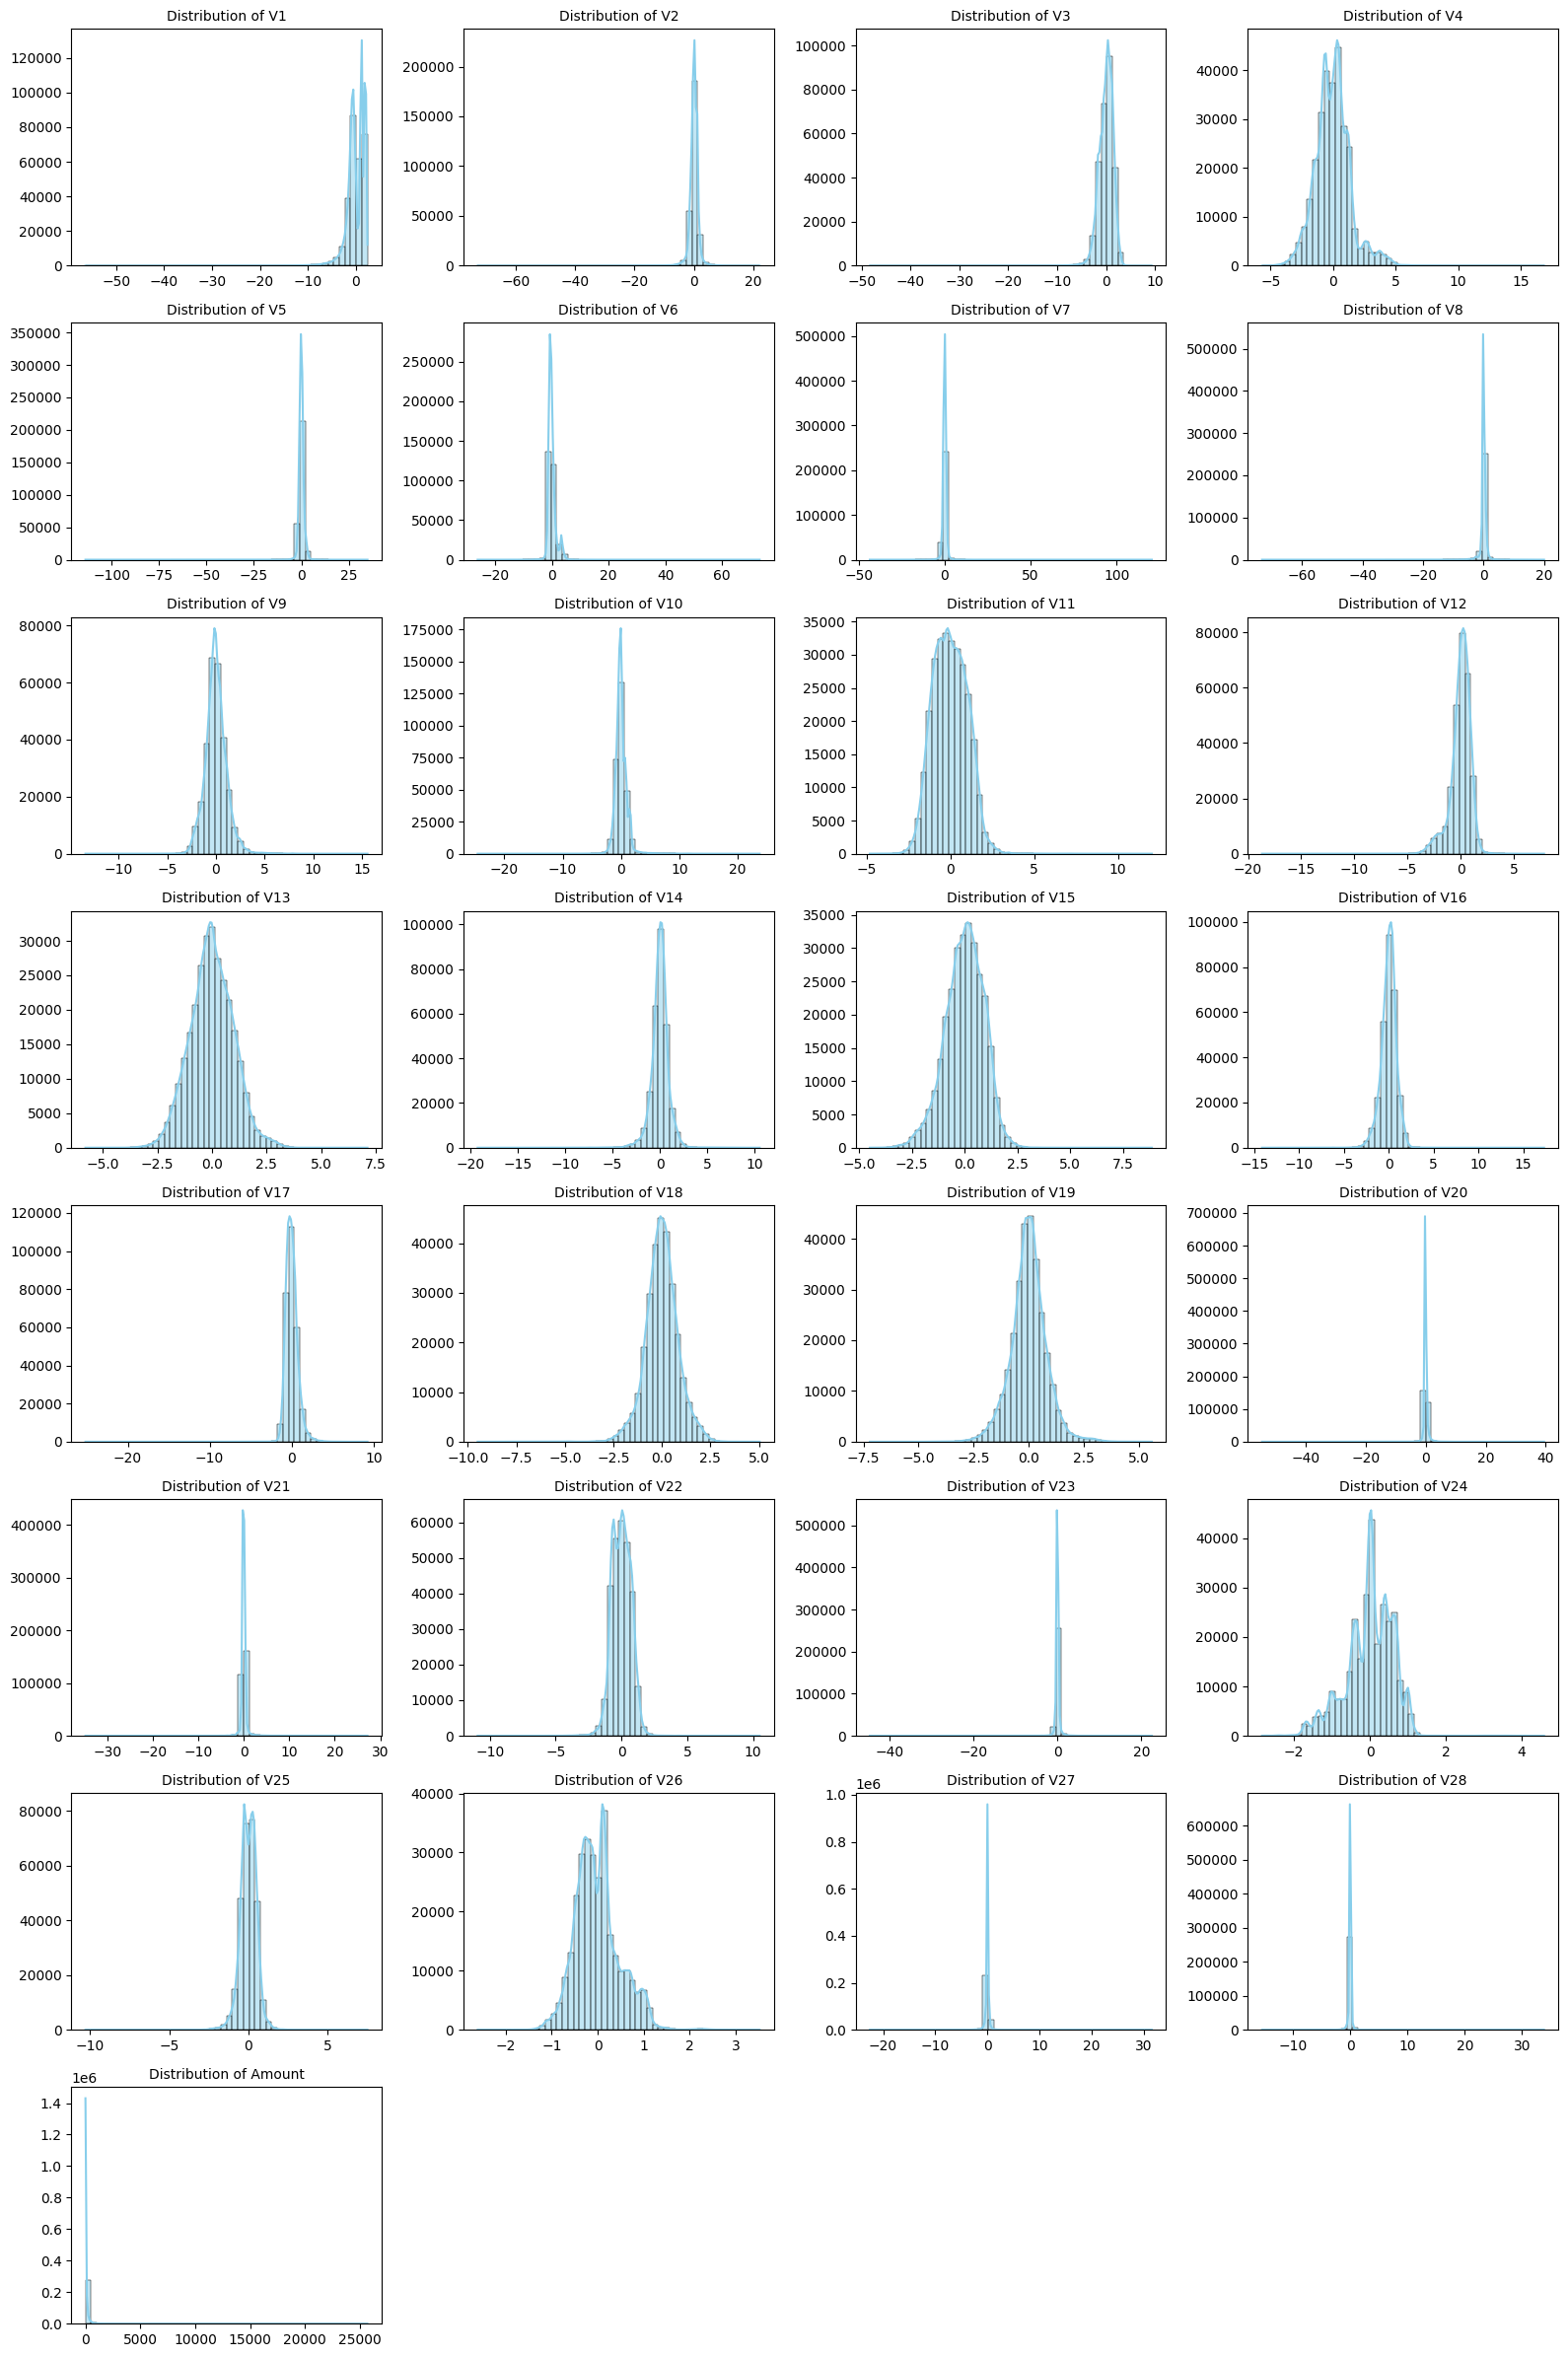

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get all columns except 'Time' and 'Class'
features = df.drop(columns=['Time', 'Class']).columns

# Determine the number of rows and columns for the subplots grid
n_cols = 4  # Number of columns in the subplot grid
n_rows = (len(features) + n_cols - 1) // n_cols # Calculate rows needed

plt.figure(figsize=(n_cols * 4, n_rows * 3))

for i, feature in enumerate(features):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df[feature], kde=True, bins=50, color='skyblue')
    plt.title(f'Distribution of {feature}', fontsize=10)
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()